# 📘 TÀI LIỆU: Xây dựng bảng `NNT_SCORE_AI` (CSDLTH_DA → CSDLTH_AI)

**Mục tiêu:** Đồng bộ dữ liệu điểm số rủi ro doanh nghiệp (`NNT_SCORE`) từ CSDLTH_DA sang CSDLTH_AI, kèm tên doanh nghiệp (`NAME` từ bảng `MST_DN`), xây dựng thành bảng `NNT_SCORE_AI` có PRIMARY KEY, PARTITION theo năm, COMMENT tiếng Việt có dấu, và một PACKAGE PL/SQL để đồng bộ lại dữ liệu bất cứ khi nào cần.

**Phạm vi dữ liệu:** 5 năm báo cáo — 2021, 2022, 2023, 2024, 2025 — tổng cộng **4,819,562 dòng**, 232 cột.

**Người thực hiện:** CUCNT11 (team DA) — dưới hướng dẫn của anh Đại / chị Nghĩa.

---
### Mục lục
1. [Bối cảnh & yêu cầu ban đầu](#buoc0)
2. [Khảo sát cấu trúc dữ liệu nguồn](#buoc1)
3. [Xác định kiến trúc: cùng 1 DB, khác schema](#buoc2)
4. [Cấp quyền GRANT giữa 2 schema](#buoc3)
5. [Tạo bảng `NNT_SCORE_AI` — PK + PARTITION + COMMENT](#buoc4)
6. [Đổ dữ liệu 5 năm vào bảng mới](#buoc5)
7. [Viết PACKAGE đồng bộ (JOIN thẳng, không VIEW/DB LINK)](#buoc6)
8. [Kiểm tra kết quả cuối cùng](#buoc7)
9. [Các lỗi đã gặp & cách xử lý](#buoc8)
9b. [**Hướng dẫn kiểm tra từng bước (test case) — ĐẠT/KHÔNG ĐẠT thì làm gì**](#buoc95)
10. [Việc còn tồn đọng cần xác nhận](#buoc9)
11. [Phụ lục: Toàn bộ script SQL](#buoc10)


<a id='buoc0'></a>
## 1. Bối cảnh & yêu cầu ban đầu

Anh Đại giao nhiệm vụ (nhắn qua chat nội bộ):

> *"Em tạo bảng thiếu PK, cmt, PARTITION cmt chuyển sang tiếng việt có dấu cho anh nhé. Luồng tổng hợp thì bỏ bảng view đi, viết thẳng câu select join đấy vào pkg, bỏ cả dbl đi vì nó cũng ở cùng một DB."*

Yêu cầu ban đầu (trước khi có chỉ đạo trên) là: lấy dữ liệu từ bảng `NNT_SCORE` (CSDLTH_DA) — lấy toàn bộ cột — và join thêm cột `NAME` (tên doanh nghiệp) từ bảng `MST_DN` (CSDLTH_DA), rồi đưa kết quả sang CSDLTH_AI.


### Dữ liệu mẫu ban đầu (bảng có cột TIN/MST và NAME)
Ảnh chụp từ Oracle SQL Developer cho thấy cấu trúc dữ liệu gốc — mỗi doanh nghiệp có mã số thuế (MST/TIN) và tên đầy đủ.

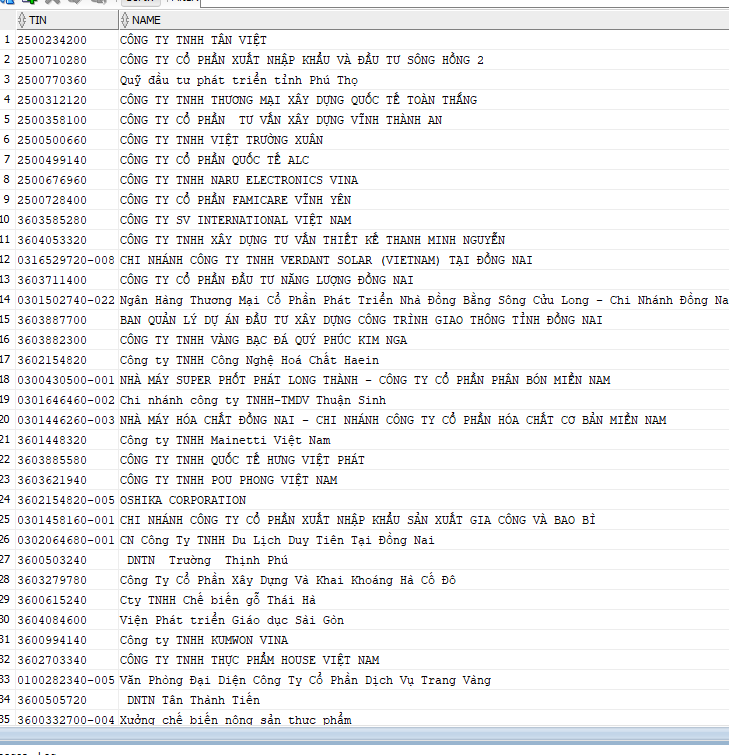

<a id='buoc1'></a>
## 2. Khảo sát cấu trúc dữ liệu nguồn

### 2.1. Bảng `NNT_SCORE` (CSDLTH_DA)
- Khóa: `(KY_BC, MST)` — mỗi doanh nghiệp có nhiều dòng theo từng năm báo cáo.
- 231 cột: các chỉ tiêu tài chính gốc (M11, M13, M14...), tỷ số tài chính (ROA, ROE, DSO, DIO...), điểm Piotroski, điểm Altman Z-Score, và điểm từ 8 mô hình ML (IsolationForest, ECOD, COPOD, HBOS, Mahalanobis, PCA, LOF, AutoEncoder) cho hệ thống phát hiện bất thường (anomaly detection ensemble).

### 2.2. Bảng `MST_DN` (CSDLTH_DA)
- Khóa: `TIN` (mã số thuế) — **khác tên cột** so với `MST` bên `NNT_SCORE`, nhưng cùng ý nghĩa (mã số thuế).
- Cột cần lấy: `NAME` (tên doanh nghiệp).


Cấu trúc bảng `NNT_SCORE` — comment gốc bằng tiếng Việt không dấu, cho thấy công thức tính từng chỉ tiêu (VD: `NON_CURRENT_ASSETS = TOTAL_ASSETS - CURRENT_ASSETS (M39 - M40)`).

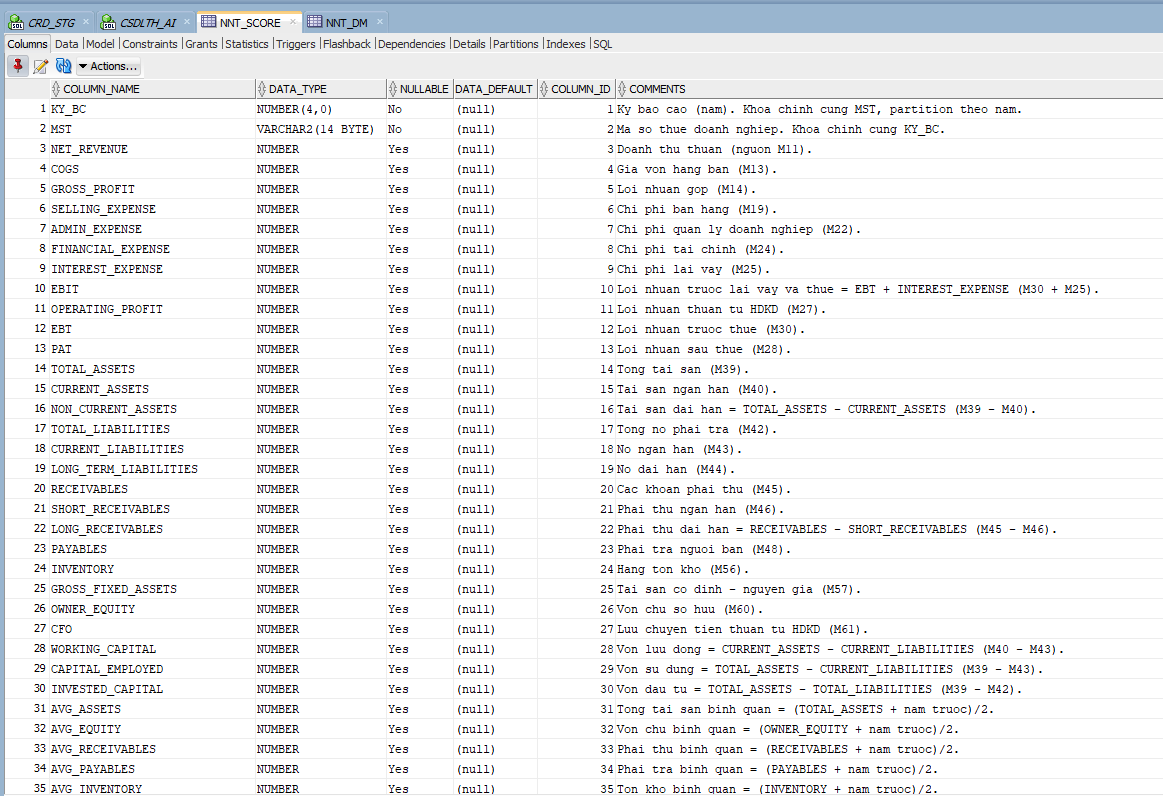

Cấu trúc bảng `MST_DN` — cột khóa là `TIN` (14 ký tự), cột `NAME` (500 ký tự) chứa tên doanh nghiệp.

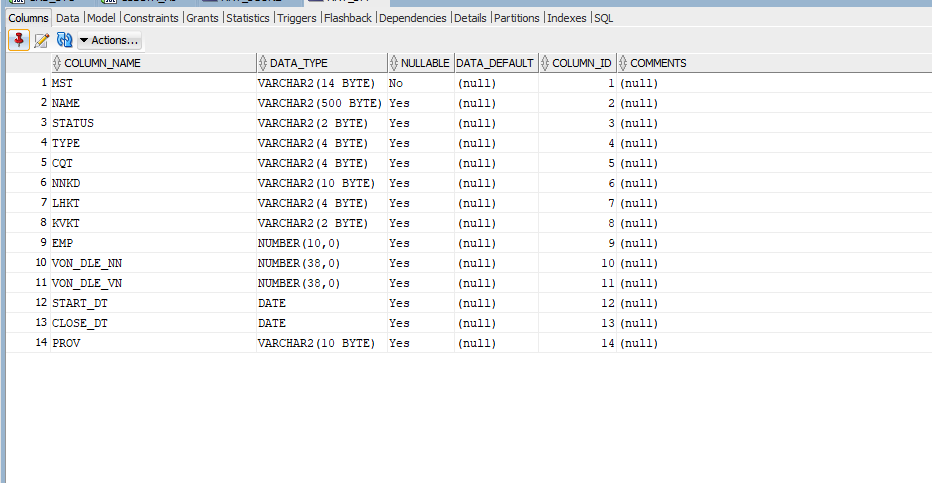

### 2.3. Câu JOIN xác định ban đầu

```sql
SELECT a.*, b.NAME
FROM NNT_SCORE a
LEFT JOIN MST_DN b
  ON a.MST = b.TIN;
```

Dùng `LEFT JOIN` (không phải `JOIN` thường) để **giữ nguyên toàn bộ dòng** của `NNT_SCORE`, kể cả khi chưa có tên doanh nghiệp tương ứng trong `MST_DN`.


<a id='buoc2'></a>
## 3. Xác định kiến trúc: CSDLTH_DA và CSDLTH_AI cùng 1 DB instance, khác schema

Ban đầu tưởng CSDLTH_DA và CSDLTH_AI là **2 database vật lý khác nhau**, nên đã thử tạo DB LINK (`CREATE DATABASE LINK`) để kết nối. Việc này dẫn tới:
- Kéo dữ liệu qua DB LINK **rất chậm** (~13-14 phút / năm, ~876 nghìn dòng).
- Phức tạp hơn cần thiết (phải quản lý thêm VIEW + DB LINK).

**Cách kiểm tra để xác nhận chỉ là 2 schema trong cùng 1 instance:**
```sql
SELECT USER FROM DUAL;
```
Chạy câu này ở cả 2 tab connection — nếu ra 2 tên user khác nhau (`CSDLTH_AI` và `CSDLTH_DA`) nhưng **cùng trỏ tới 1 host/port** (kiểm tra qua `user_db_links` hoặc thông tin connection), thì đó là 2 schema cùng 1 DB → **không cần DB LINK**, chỉ cần `GRANT` quyền và gọi thẳng `SCHEMA.TABLE`.

**Bài học:** Luôn xác nhận kiến trúc hạ tầng thật trước khi chọn giải pháp kỹ thuật — đỡ phải làm đi làm lại như trong dự án này.


<a id='buoc3'></a>
## 4. Cấp quyền GRANT giữa 2 schema

Vì 2 bảng nguồn (`NNT_SCORE`, `MST_DN`) thuộc schema `CSDLTH_DA`, cần cấp quyền `SELECT` cho schema `CSDLTH_AI` mới đọc được.

**⚠️ Lưu ý quan trọng:** câu lệnh `GRANT` phải chạy từ **schema chủ sở hữu** (`CSDLTH_DA`), không phải từ `CSDLTH_AI` — nếu chạy sai chiều sẽ gặp lỗi `ORA-01749: Cannot GRANT or REVOKE privileges to or from yourself`.


Lỗi khi chạy GRANT sai chiều (chạy từ CSDLTH_AI, tự cấp quyền cho chính mình).

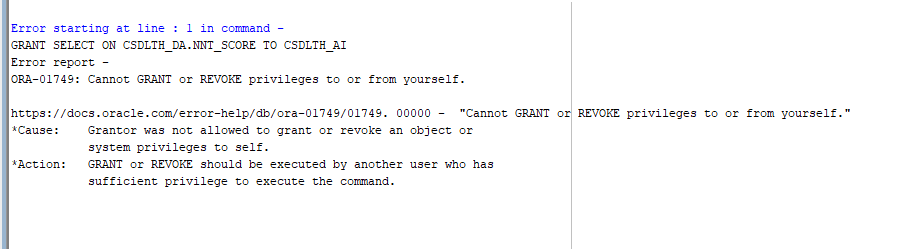

**Cách sửa — chạy đúng ở tab CSDLTH_DA (chủ sở hữu bảng):**
```sql
GRANT SELECT ON NNT_SCORE TO CSDLTH_AI;
GRANT SELECT ON MST_DN TO CSDLTH_AI;
```


GRANT chạy đúng ở tab CSDLTH_DA — kết quả `Grant succeeded.` x2.

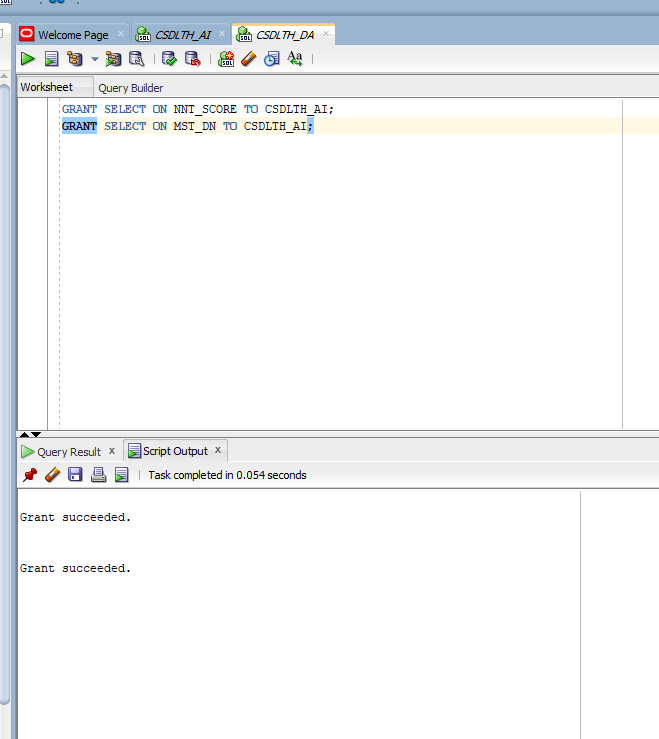

**Kiểm tra quyền đã hoạt động (chạy ở tab CSDLTH_AI):**
```sql
SELECT COUNT(*) FROM CSDLTH_DA.NNT_SCORE;
SELECT COUNT(*) FROM CSDLTH_DA.MST_DN;
```
Kết quả: `NNT_SCORE` = 4,819,562 dòng, `MST_DN` = 3,209,436 dòng — quyền đọc hoạt động chính xác.


<a id='buoc4'></a>
## 5. Tạo bảng `NNT_SCORE_AI` — PRIMARY KEY + PARTITION + COMMENT tiếng Việt

### 5.1. Vì sao cần PRIMARY KEY `(KY_BC, MST)`
- **Chống trùng dữ liệu**: đảm bảo mỗi doanh nghiệp chỉ có đúng 1 dòng / năm. Nếu package chạy nhầm 2 lần cho cùng 1 năm mà quên xóa trước, Oracle sẽ tự báo lỗi thay vì âm thầm insert trùng.
- **Tăng tốc truy vấn** theo `MST` + `KY_BC` nhờ index ngầm của PK.

### 5.2. Vì sao cần PARTITION BY RANGE (KY_BC)
- Mỗi năm dữ liệu lưu tách biệt vật lý trên đĩa (giống mỗi năm 1 ngăn kéo riêng trong tủ hồ sơ).
- Khi query `WHERE KY_BC = 2024`, Oracle chỉ đọc đúng 1 partition thay vì quét cả 4.8 triệu dòng.
- Khi package `DELETE ... WHERE KY_BC = p_ky_bc`, chỉ ảnh hưởng đúng 1 partition, không khóa (lock) dữ liệu các năm khác.

### 5.3. Comment tiếng Việt có dấu
Được dịch chính xác từ file mô tả chính thức (`DATA_DESSCRIPTION_NNT_SCORE.csv`) do team cung cấp — giữ nguyên công thức tính (VD: `ROA = PAT / AVG_ASSETS`), không suy đoán tùy tiện.

**Lưu ý:** 8 cột `LOF_SCORE, LOF_RANK, LOF_CONTRIB, AE_SCORE, AE_RANK, AE_CONTRIB, SCORE, RANK` KHÔNG có comment gốc trong file mô tả — đã đánh dấu `[CAN XAC NHAN]`, xem mục 9 bên dưới.


Kiểm tra cấu trúc bảng mới — 232 cột, cột `NAME` (VARCHAR2) ở vị trí cuối (232) trong bản đầu tiên, sau đó được đưa lên vị trí thứ 3 khi rebuild lại theo yêu cầu "để cạnh MST cho dễ theo dõi".

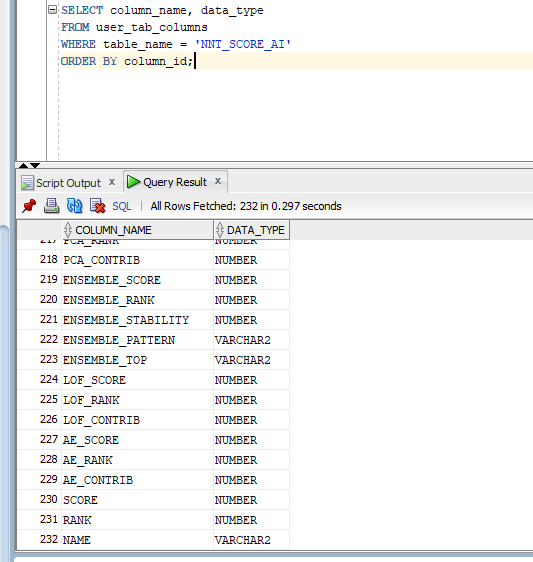

Toàn bộ comment tiếng Việt có dấu chạy thành công (`Comment created.` lặp lại theo từng cột).

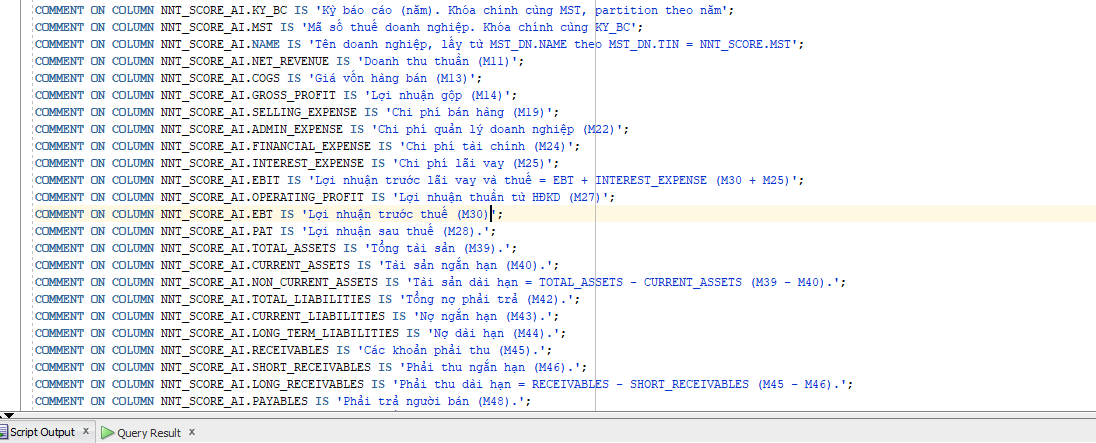

<a id='buoc5'></a>
## 6. Đổ dữ liệu 5 năm vào bảng mới

### 6.1. Cách làm đầu tiên (có vấn đề) — insert cả 4.8 triệu dòng 1 lần từ bảng backup
```sql
INSERT INTO NNT_SCORE_AI (...)
SELECT ... FROM NNT_SCORE_AI_OLD;
```
→ Gặp lỗi **`ORA-01688: unable to extend table ... partition P_2022 by 1024 in tablespace`** — hết dung lượng tablespace, vì phải giữ đồng thời 2 bản (bảng cũ backup + bảng mới đang insert) = cần gấp đôi dung lượng tạm thời.


Lỗi ORA-01688 — hết dung lượng tablespace khi insert đồng thời cả 4.8 triệu dòng.

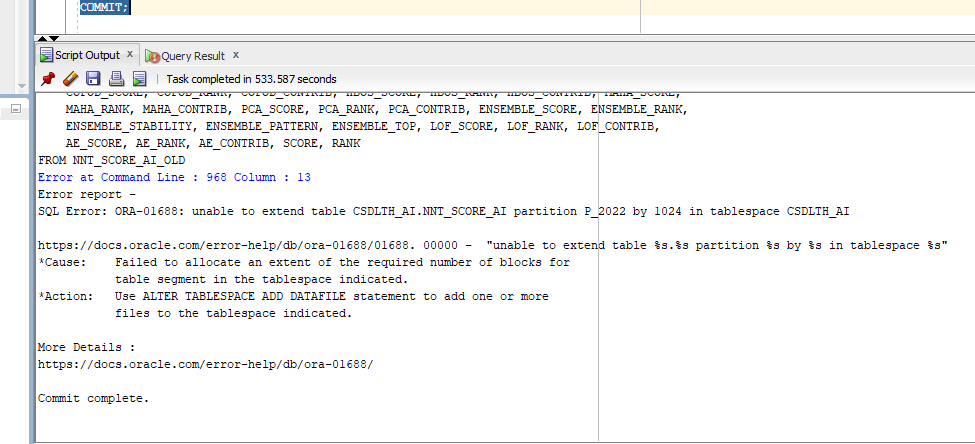

### 6.2. Cách làm đúng — bỏ bảng backup, insert trực tiếp từ nguồn theo từng năm
Xóa hẳn bảng backup, insert thẳng từ `CSDLTH_DA.NNT_SCORE` JOIN `CSDLTH_DA.MST_DN`, chia theo từng năm để giảm áp lực dung lượng và dễ kiểm soát lỗi.

```sql
DROP TABLE NNT_SCORE_AI_OLD PURGE;

INSERT INTO NNT_SCORE_AI (
    KY_BC,
    MST,
    NAME,
    NET_REVENUE,
    COGS,
    GROSS_PROFIT,
    SELLING_EXPENSE,
    ADMIN_EXPENSE,
    FINANCIAL_EXPENSE,
    INTEREST_EXPENSE,
    EBIT,
    OPERATING_PROFIT,
    EBT,
    PAT,
    TOTAL_ASSETS,
    CURRENT_ASSETS,
    NON_CURRENT_ASSETS,
    TOTAL_LIABILITIES,
    CURRENT_LIABILITIES,
    LONG_TERM_LIABILITIES,
    RECEIVABLES,
    SHORT_RECEIVABLES,
    LONG_RECEIVABLES,
    PAYABLES,
    INVENTORY,
    GROSS_FIXED_ASSETS,
    OWNER_EQUITY,
    CFO,
    WORKING_CAPITAL,
    CAPITAL_EMPLOYED,
    INVESTED_CAPITAL,
    AVG_ASSETS,
    AVG_EQUITY,
    AVG_RECEIVABLES,
    AVG_PAYABLES,
    AVG_INVENTORY,
    AVG_FIXED_ASSETS,
    OWNER_EQUITY_CHANGE,
    REVENUE_GROWTH,
    PROFIT_GROWTH,
    CFO_GROWTH,
    ASSET_GROWTH,
    EQUITY_GROWTH,
    RECEIVABLE_GROWTH,
    PAYABLE_GROWTH,
    INVENTORY_GROWTH,
    FLAG_MISSING_REVENUE,
    FLAG_MISSING_ASSETS,
    FLAG_INVALID_ASSETS,
    FLAG_MISSING_CFO,
    FLAG_ZERO_REVENUE,
    FLAG_INVALID_CURRENT_LIAB,
    FLAG_MISSING_PRIOR_YEAR,
    IS_SCORABLE,
    ROA,
    ROE,
    ROA_EBIT,
    ROCE,
    GROSS_MARGIN,
    OPERATING_MARGIN,
    EBIT_MARGIN,
    PRETAX_MARGIN,
    NET_MARGIN,
    CASH_ROA,
    CASH_ROE,
    GROSS_RETURN_ON_ASSETS,
    CURRENT_RATIO,
    QUICK_RATIO,
    WORKING_CAPITAL_RATIO,
    CFO_CURRENT_LIAB,
    CFO_WORKING_CAPITAL,
    OPERATING_CASH_MARGIN,
    DEBT_RATIO,
    DEBT_TO_EQUITY,
    EQUITY_RATIO,
    EQUITY_MULTIPLIER_EOY,
    LT_DEBT_RATIO,
    LT_DEBT_TO_CAPITAL,
    INTEREST_COVERAGE,
    ASSET_TO_DEBT,
    ASSET_TURNOVER_EOY,
    CFO_TO_DEBT,
    CASH_INTEREST_COVERAGE,
    CASH_EARNINGS_DIFFERENCE,
    CASH_EARNINGS_RATIO,
    ACCRUAL_RATIO,
    CASH_CONVERSION_EFFICIENCY,
    CURRENT_ASSET_PERCENT,
    NON_CURRENT_ASSET_PERCENT,
    INVENTORY_PERCENT,
    RECEIVABLE_PERCENT,
    PAYABLE_PERCENT,
    FIXED_ASSET_PERCENT,
    CAPITAL_EMPLOYED_RATIO,
    INVESTED_CAPITAL_RATIO,
    WORKING_CAPITAL_TO_SALES,
    ASSET_TURNOVER,
    INVENTORY_TURNOVER,
    RECEIVABLE_TURNOVER,
    PAYABLE_TURNOVER,
    FIXED_ASSET_TURNOVER,
    WORKING_CAPITAL_TURNOVER,
    FIXED_ASSET_RETURN,
    DSO,
    DIO,
    DPO,
    OPERATING_CYCLE,
    CASH_CONVERSION_CYCLE,
    EQUITY_MULTIPLIER,
    DUPONT_ROE,
    RECEIVABLE_GROWTH_GAP,
    INVENTORY_GROWTH_GAP,
    INV_SELL_COUNT,
    INV_SELL_NET,
    INV_BUY_COUNT,
    INV_BUY_NET,
    INV_AVG_SELL_VALUE,
    INV_AVG_BUY_VALUE,
    INV_IO_RATIO,
    INV_VAT_NET,
    INV_VAT_RATE_OUT,
    INV_VAT_RATE_IN,
    INV_SELL_GROWTH,
    INV_BUY_GROWTH,
    INV_SELL_CNT_GROWTH,
    INV_BUY_CNT_GROWTH,
    INV_AVG_VALUE_GROWTH,
    INV_IO_RATIO_CHANGE,
    REV_INVOICE_GAP,
    REV_GROWTH_XSOURCE_GAP,
    VAT_RATE_DEVIATION,
    FLAG_REV_UNDERREPORT,
    FLAG_REV_NO_INVOICE,
    FLAG_HIGH_INPUT_NO_STOCK,
    FLAG_AVG_VALUE_SPIKE,
    ALTMAN_X1,
    ALTMAN_X3,
    ALTMAN_X4,
    ALTMAN_X5,
    PF_POSITIVE_ROA,
    PF_POSITIVE_CFO,
    PF_ROA_IMPROVED,
    PF_ACCRUAL,
    PF_LEVERAGE_DECREASED,
    PF_LIQUIDITY_IMPROVED,
    PF_NO_DILUTION,
    PF_MARGIN_IMPROVED,
    PF_TURNOVER_IMPROVED,
    FLAG_NEGATIVE_EQUITY,
    FLAG_NEGATIVE_PAT,
    FLAG_NEGATIVE_CFO,
    FLAG_LOW_CURRENT_RATIO,
    FLAG_HIGH_DEBT,
    FLAG_LOW_INTEREST_COVERAGE,
    FLAG_RECEIVABLE_SPIKE,
    FLAG_INVENTORY_SPIKE,
    FLAG_LOW_EARNINGS_QUALITY,
    ALTMAN_Z_SCORE,
    PIOTROSKI_SCORE,
    CASHFLOW_RISK,
    GROWTH_RISK,
    EARNINGS_QUALITY,
    FRAUD_FLAGS,
    DISTRESS_FLAGS,
    TOTAL_RISK_FLAGS,
    IC_ADJ,
    PS_ROA,
    PS_NET_MARGIN,
    PS_CASH_ROA,
    PS_DEBT_RATIO,
    PS_LT_DEBT_CAP,
    PS_INT_COVERAGE,
    PS_CFO_TO_DEBT,
    PS_CURRENT_RATIO,
    PS_QUICK_RATIO,
    PS_OPER_CASH_MARGIN,
    PS_ACCRUAL,
    PS_CASH_EARNINGS,
    PS_REVENUE_GROWTH,
    PS_ASSET_GROWTH,
    PS_SIZE,
    RELATIVE_SCORE,
    ALTMAN_SCORE,
    PIOTROSKI_PERCENT,
    CASHFLOW_SCORE,
    GROWTH_SCORE,
    EARNINGS_QUALITY_SCORE,
    FRAUD_SCORE,
    DISTRESS_SCORE,
    FLAG_SCORE,
    CREDIT_SCORE,
    ENTERPRISE_SCORE,
    INTERNAL_RATING,
    RISK_LEVEL,
    F_ROA_X_CURRENT,
    F_ROE_X_DEBT,
    F_DUPONT_COMPONENT,
    F_CASH_STRENGTH,
    F_FRAUD_SIGNAL,
    IF_SCORE,
    EXPLAIN_TOP,
    EXPLAIN_SHAP,
    IF_RANK,
    IF_CONTRIB,
    ECOD_SCORE,
    ECOD_RANK,
    ECOD_CONTRIB,
    COPOD_SCORE,
    COPOD_RANK,
    COPOD_CONTRIB,
    HBOS_SCORE,
    HBOS_RANK,
    HBOS_CONTRIB,
    MAHA_SCORE,
    MAHA_RANK,
    MAHA_CONTRIB,
    PCA_SCORE,
    PCA_RANK,
    PCA_CONTRIB,
    ENSEMBLE_SCORE,
    ENSEMBLE_RANK,
    ENSEMBLE_STABILITY,
    ENSEMBLE_PATTERN,
    ENSEMBLE_TOP,
    LOF_SCORE,
    LOF_RANK,
    LOF_CONTRIB,
    AE_SCORE,
    AE_RANK,
    AE_CONTRIB,
    SCORE,
    RANK
)
SELECT
    a.KY_BC,
    a.MST,
    b.NAME,
    a.NET_REVENUE,
    a.COGS,
    a.GROSS_PROFIT,
    a.SELLING_EXPENSE,
    a.ADMIN_EXPENSE,
    a.FINANCIAL_EXPENSE,
    a.INTEREST_EXPENSE,
    a.EBIT,
    a.OPERATING_PROFIT,
    a.EBT,
    a.PAT,
    a.TOTAL_ASSETS,
    a.CURRENT_ASSETS,
    a.NON_CURRENT_ASSETS,
    a.TOTAL_LIABILITIES,
    a.CURRENT_LIABILITIES,
    a.LONG_TERM_LIABILITIES,
    a.RECEIVABLES,
    a.SHORT_RECEIVABLES,
    a.LONG_RECEIVABLES,
    a.PAYABLES,
    a.INVENTORY,
    a.GROSS_FIXED_ASSETS,
    a.OWNER_EQUITY,
    a.CFO,
    a.WORKING_CAPITAL,
    a.CAPITAL_EMPLOYED,
    a.INVESTED_CAPITAL,
    a.AVG_ASSETS,
    a.AVG_EQUITY,
    a.AVG_RECEIVABLES,
    a.AVG_PAYABLES,
    a.AVG_INVENTORY,
    a.AVG_FIXED_ASSETS,
    a.OWNER_EQUITY_CHANGE,
    a.REVENUE_GROWTH,
    a.PROFIT_GROWTH,
    a.CFO_GROWTH,
    a.ASSET_GROWTH,
    a.EQUITY_GROWTH,
    a.RECEIVABLE_GROWTH,
    a.PAYABLE_GROWTH,
    a.INVENTORY_GROWTH,
    a.FLAG_MISSING_REVENUE,
    a.FLAG_MISSING_ASSETS,
    a.FLAG_INVALID_ASSETS,
    a.FLAG_MISSING_CFO,
    a.FLAG_ZERO_REVENUE,
    a.FLAG_INVALID_CURRENT_LIAB,
    a.FLAG_MISSING_PRIOR_YEAR,
    a.IS_SCORABLE,
    a.ROA,
    a.ROE,
    a.ROA_EBIT,
    a.ROCE,
    a.GROSS_MARGIN,
    a.OPERATING_MARGIN,
    a.EBIT_MARGIN,
    a.PRETAX_MARGIN,
    a.NET_MARGIN,
    a.CASH_ROA,
    a.CASH_ROE,
    a.GROSS_RETURN_ON_ASSETS,
    a.CURRENT_RATIO,
    a.QUICK_RATIO,
    a.WORKING_CAPITAL_RATIO,
    a.CFO_CURRENT_LIAB,
    a.CFO_WORKING_CAPITAL,
    a.OPERATING_CASH_MARGIN,
    a.DEBT_RATIO,
    a.DEBT_TO_EQUITY,
    a.EQUITY_RATIO,
    a.EQUITY_MULTIPLIER_EOY,
    a.LT_DEBT_RATIO,
    a.LT_DEBT_TO_CAPITAL,
    a.INTEREST_COVERAGE,
    a.ASSET_TO_DEBT,
    a.ASSET_TURNOVER_EOY,
    a.CFO_TO_DEBT,
    a.CASH_INTEREST_COVERAGE,
    a.CASH_EARNINGS_DIFFERENCE,
    a.CASH_EARNINGS_RATIO,
    a.ACCRUAL_RATIO,
    a.CASH_CONVERSION_EFFICIENCY,
    a.CURRENT_ASSET_PERCENT,
    a.NON_CURRENT_ASSET_PERCENT,
    a.INVENTORY_PERCENT,
    a.RECEIVABLE_PERCENT,
    a.PAYABLE_PERCENT,
    a.FIXED_ASSET_PERCENT,
    a.CAPITAL_EMPLOYED_RATIO,
    a.INVESTED_CAPITAL_RATIO,
    a.WORKING_CAPITAL_TO_SALES,
    a.ASSET_TURNOVER,
    a.INVENTORY_TURNOVER,
    a.RECEIVABLE_TURNOVER,
    a.PAYABLE_TURNOVER,
    a.FIXED_ASSET_TURNOVER,
    a.WORKING_CAPITAL_TURNOVER,
    a.FIXED_ASSET_RETURN,
    a.DSO,
    a.DIO,
    a.DPO,
    a.OPERATING_CYCLE,
    a.CASH_CONVERSION_CYCLE,
    a.EQUITY_MULTIPLIER,
    a.DUPONT_ROE,
    a.RECEIVABLE_GROWTH_GAP,
    a.INVENTORY_GROWTH_GAP,
    a.INV_SELL_COUNT,
    a.INV_SELL_NET,
    a.INV_BUY_COUNT,
    a.INV_BUY_NET,
    a.INV_AVG_SELL_VALUE,
    a.INV_AVG_BUY_VALUE,
    a.INV_IO_RATIO,
    a.INV_VAT_NET,
    a.INV_VAT_RATE_OUT,
    a.INV_VAT_RATE_IN,
    a.INV_SELL_GROWTH,
    a.INV_BUY_GROWTH,
    a.INV_SELL_CNT_GROWTH,
    a.INV_BUY_CNT_GROWTH,
    a.INV_AVG_VALUE_GROWTH,
    a.INV_IO_RATIO_CHANGE,
    a.REV_INVOICE_GAP,
    a.REV_GROWTH_XSOURCE_GAP,
    a.VAT_RATE_DEVIATION,
    a.FLAG_REV_UNDERREPORT,
    a.FLAG_REV_NO_INVOICE,
    a.FLAG_HIGH_INPUT_NO_STOCK,
    a.FLAG_AVG_VALUE_SPIKE,
    a.ALTMAN_X1,
    a.ALTMAN_X3,
    a.ALTMAN_X4,
    a.ALTMAN_X5,
    a.PF_POSITIVE_ROA,
    a.PF_POSITIVE_CFO,
    a.PF_ROA_IMPROVED,
    a.PF_ACCRUAL,
    a.PF_LEVERAGE_DECREASED,
    a.PF_LIQUIDITY_IMPROVED,
    a.PF_NO_DILUTION,
    a.PF_MARGIN_IMPROVED,
    a.PF_TURNOVER_IMPROVED,
    a.FLAG_NEGATIVE_EQUITY,
    a.FLAG_NEGATIVE_PAT,
    a.FLAG_NEGATIVE_CFO,
    a.FLAG_LOW_CURRENT_RATIO,
    a.FLAG_HIGH_DEBT,
    a.FLAG_LOW_INTEREST_COVERAGE,
    a.FLAG_RECEIVABLE_SPIKE,
    a.FLAG_INVENTORY_SPIKE,
    a.FLAG_LOW_EARNINGS_QUALITY,
    a.ALTMAN_Z_SCORE,
    a.PIOTROSKI_SCORE,
    a.CASHFLOW_RISK,
    a.GROWTH_RISK,
    a.EARNINGS_QUALITY,
    a.FRAUD_FLAGS,
    a.DISTRESS_FLAGS,
    a.TOTAL_RISK_FLAGS,
    a.IC_ADJ,
    a.PS_ROA,
    a.PS_NET_MARGIN,
    a.PS_CASH_ROA,
    a.PS_DEBT_RATIO,
    a.PS_LT_DEBT_CAP,
    a.PS_INT_COVERAGE,
    a.PS_CFO_TO_DEBT,
    a.PS_CURRENT_RATIO,
    a.PS_QUICK_RATIO,
    a.PS_OPER_CASH_MARGIN,
    a.PS_ACCRUAL,
    a.PS_CASH_EARNINGS,
    a.PS_REVENUE_GROWTH,
    a.PS_ASSET_GROWTH,
    a.PS_SIZE,
    a.RELATIVE_SCORE,
    a.ALTMAN_SCORE,
    a.PIOTROSKI_PERCENT,
    a.CASHFLOW_SCORE,
    a.GROWTH_SCORE,
    a.EARNINGS_QUALITY_SCORE,
    a.FRAUD_SCORE,
    a.DISTRESS_SCORE,
    a.FLAG_SCORE,
    a.CREDIT_SCORE,
    a.ENTERPRISE_SCORE,
    a.INTERNAL_RATING,
    a.RISK_LEVEL,
    a.F_ROA_X_CURRENT,
    a.F_ROE_X_DEBT,
    a.F_DUPONT_COMPONENT,
    a.F_CASH_STRENGTH,
    a.F_FRAUD_SIGNAL,
    a.IF_SCORE,
    a.EXPLAIN_TOP,
    a.EXPLAIN_SHAP,
    a.IF_RANK,
    a.IF_CONTRIB,
    a.ECOD_SCORE,
    a.ECOD_RANK,
    a.ECOD_CONTRIB,
    a.COPOD_SCORE,
    a.COPOD_RANK,
    a.COPOD_CONTRIB,
    a.HBOS_SCORE,
    a.HBOS_RANK,
    a.HBOS_CONTRIB,
    a.MAHA_SCORE,
    a.MAHA_RANK,
    a.MAHA_CONTRIB,
    a.PCA_SCORE,
    a.PCA_RANK,
    a.PCA_CONTRIB,
    a.ENSEMBLE_SCORE,
    a.ENSEMBLE_RANK,
    a.ENSEMBLE_STABILITY,
    a.ENSEMBLE_PATTERN,
    a.ENSEMBLE_TOP,
    a.LOF_SCORE,
    a.LOF_RANK,
    a.LOF_CONTRIB,
    a.AE_SCORE,
    a.AE_RANK,
    a.AE_CONTRIB,
    a.SCORE,
    a.RANK
FROM CSDLTH_DA.NNT_SCORE a
LEFT JOIN CSDLTH_DA.MST_DN b
  ON a.MST = b.TIN
WHERE a.KY_BC = 2021;

COMMIT;
```


Insert năm 2021 thành công trực tiếp từ nguồn (không qua bảng backup) — `876,268 rows inserted.`

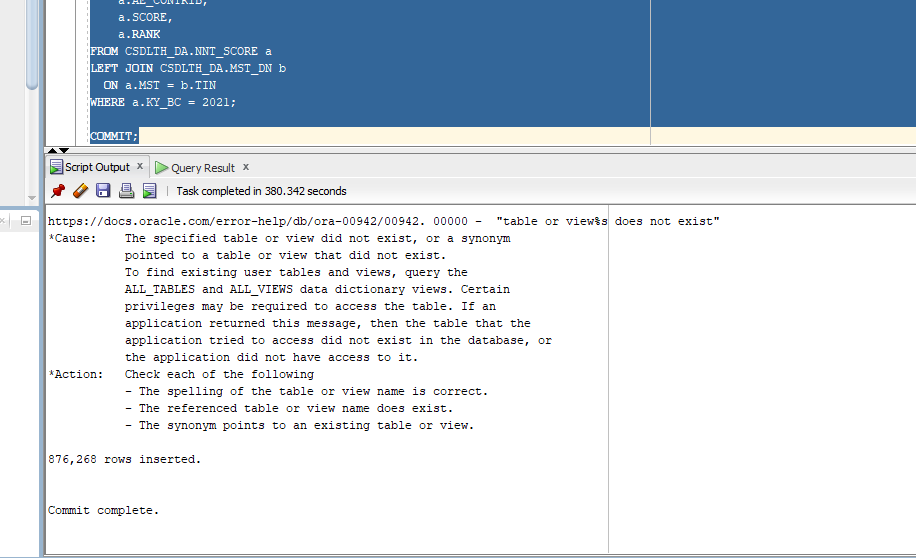

Kết quả cuối cùng sau khi chạy đủ 5 năm — khớp chính xác 100% với số liệu gốc.

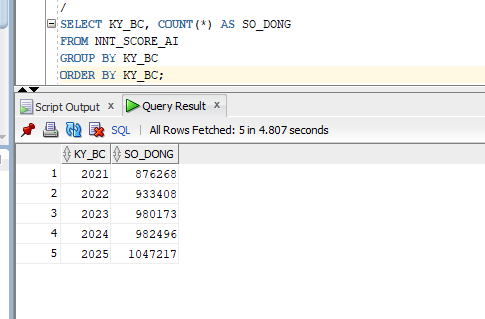

| Năm | Số dòng | Đối chiếu nguồn |
|---|---|---|
| 2021 | 876,268 | ✅ khớp |
| 2022 | 933,408 | ✅ khớp |
| 2023 | 980,173 | ✅ khớp |
| 2024 | 982,496 | ✅ khớp |
| 2025 | 1,047,217 | ✅ khớp |
| **Tổng** | **4,819,562** | **✅ khớp 100%** |


<a id='buoc6'></a>
## 7. Viết PACKAGE đồng bộ (bỏ VIEW, bỏ DB LINK — theo đúng chỉ đạo của anh Đại)

### 7.1. Dọn dẹp phần không cần dùng nữa
```sql
-- Chay o tab CSDLTH_DA
DROP VIEW V_NNT_SCORE_FULL;

-- Chay o tab CSDLTH_AI
DROP DATABASE LINK LNK_CSDLTH_DA;
```

### 7.2. Vì sao cần PACKAGE (không chỉ chạy tay 1 lần)
- **Tái sử dụng**: khi có năm mới (VD 2026) hoặc cần re-sync 1 năm, chỉ cần gọi 1 dòng lệnh thay vì copy-paste lại toàn bộ câu lệnh 232 cột.
- **Tự động hóa**: có thể gắn vào `DBMS_SCHEDULER` để chạy định kỳ.
- **An toàn**: có `DELETE` trước `INSERT` (chống trùng) và khối `EXCEPTION ... ROLLBACK` (tự dọn dẹp nếu lỗi giữa chừng).
- **Chuẩn hóa & bàn giao**: người khác trong team chỉ cần biết gọi tên package, không cần hiểu toàn bộ logic JOIN phức tạp bên trong.

### 7.3. Package hoàn chỉnh — JOIN viết thẳng bên trong (không qua VIEW/DB LINK)


Package và Package Body compile thành công — `Package PKG_SYNC_NNT_SCORE_AI compiled` / `Package Body PKG_SYNC_NNT_SCORE_AI compiled`.

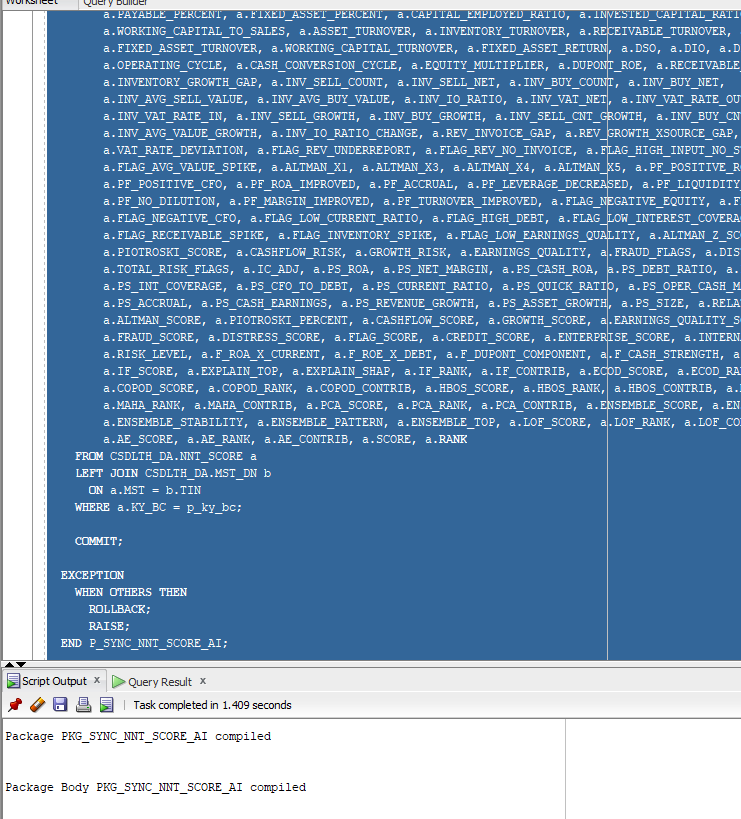

### 7.4. Cách gọi package để đồng bộ lại 1 năm bất kỳ (dùng về sau)
```sql
BEGIN
  PKG_SYNC_NNT_SCORE_AI.P_SYNC_NNT_SCORE_AI(2026);  -- doi so nam can dong bo
END;
/
```

**⚠️ Lưu ý khi có năm mới ngoài phạm vi PARTITION đã tạo (VD 2026):**
Dữ liệu năm 2026 sẽ tự động rơi vào `PARTITION P_MAX` (gom chung, mất lợi ích tách theo năm). Nên tách partition riêng trước khi đồng bộ năm mới:
```sql
ALTER TABLE NNT_SCORE_AI
SPLIT PARTITION P_MAX AT (2027)
INTO (PARTITION P_2026, PARTITION P_MAX);
```


<a id='buoc7'></a>
## 8. Kiểm tra kết quả cuối cùng

Sau khi viết lại package (JOIN trực tiếp, không VIEW/DB LINK), test lại bằng cách re-sync năm 2025 để xác nhận logic mới cho kết quả giống hệt logic cũ:
```sql
BEGIN
  PKG_SYNC_NNT_SCORE_AI.P_SYNC_NNT_SCORE_AI(2025);
END;
/

SELECT COUNT(*) FROM NNT_SCORE_AI WHERE KY_BC = 2025;
-- ky vong: 1047217
```


Kết quả sau khi chạy lại package mới (JOIN trực tiếp qua schema) cho năm 2025 — vẫn khớp chính xác 1,047,217 dòng như trước, xác nhận logic mới hoạt động đúng.

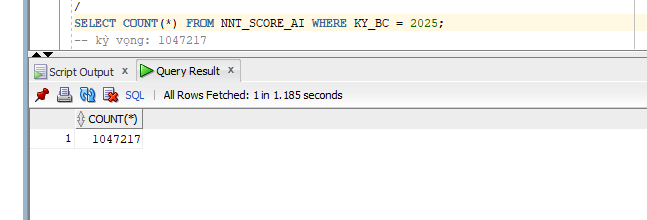

### ✅ Checklist hoàn thành
- [x] Bảng `NNT_SCORE_AI` có PRIMARY KEY `(KY_BC, MST)`
- [x] PARTITION BY RANGE theo `KY_BC` (P_2021 → P_2025, P_MAX)
- [x] Comment tiếng Việt có dấu cho bảng + 232 cột
- [x] Cột `NAME` ở vị trí thứ 3 (cạnh MST)
- [x] Đầy đủ dữ liệu 5 năm, khớp 100% với nguồn (4,819,562 dòng)
- [x] Bỏ VIEW `V_NNT_SCORE_FULL`
- [x] Bỏ DATABASE LINK `LNK_CSDLTH_DA`
- [x] Câu JOIN viết thẳng trong `PACKAGE BODY PKG_SYNC_NNT_SCORE_AI`
- [x] Test lại package mới — kết quả khớp với logic cũ


<a id='buoc8'></a>
## 9. Các lỗi đã gặp & cách xử lý (tra cứu nhanh khi gặp lại)

| Lỗi | Nguyên nhân | Cách xử lý |
|---|---|---|
| `ORA-02019: connection description for remote database not found` | DB LINK chưa được tạo | Tạo DB LINK trước, hoặc kiểm tra đã tạo đúng schema chưa |
| `ORA-00955: name is already used by an existing object` | Chạy lại `CREATE TABLE`/`CREATE DATABASE LINK` khi đối tượng đã tồn tại | Bỏ qua nếu chỉ chạy nhầm lại; hoặc `DROP` trước khi tạo lại |
| `ORA-01749: Cannot GRANT or REVOKE privileges to or from yourself` | Chạy `GRANT` từ đúng schema đang muốn tự cấp quyền cho chính mình | Chạy `GRANT` từ schema **chủ sở hữu** bảng (không phải schema nhận quyền) |
| `ORA-01688: unable to extend table ... partition ... in tablespace` | Tablespace hết dung lượng (thường do giữ đồng thời 2 bản dữ liệu — cũ + mới) | Xóa bảng backup không cần thiết trước; hoặc nhờ DBA mở rộng tablespace |
| `ORA-00942: table or view does not exist` | Gõ sai tên bảng, thiếu tiền tố schema, hoặc chưa được GRANT quyền | Kiểm tra tên bảng, thêm tiền tố `SCHEMA.`, xác nhận đã GRANT |
| Insert bị dừng giữa chừng, `SELECT COUNT(*)` ra 0 | Do người dùng chủ động dừng script, hoặc lỗi giữa chừng khiến toàn bộ `INSERT` bị rollback | `INSERT ... SELECT` là 1 khối nguyên vẹn (atomic) — nếu dừng/lỗi giữa chừng, **toàn bộ bị hủy**, không giữ lại phần dở dang. Phải chạy lại từ đầu, để chạy hết không dừng giữa chừng |


<a id='buoc95'></a>
## 9b. Hướng dẫn kiểm tra từng bước (test case) — ĐẠT thì làm gì, KHÔNG ĐẠT thì làm gì

Mục này dùng để **tự kiểm tra lại toàn bộ hệ thống** bất cứ lúc nào (kể cả sau khi đã xong, hoặc khi nghi ngờ có gì đó sai). Chạy tuần tự từng test case theo đúng thứ tự — vì test sau thường phụ thuộc vào test trước đã ĐẠT.


### 🧪 Test case 1 — Đã GRANT quyền đọc giữa 2 schema chưa?

**Chạy ở tab CSDLTH_AI:**
```sql
SELECT COUNT(*) FROM CSDLTH_DA.NNT_SCORE;
SELECT COUNT(*) FROM CSDLTH_DA.MST_DN;
```
**Kỳ vọng:** ra số dòng (VD 4819562 và 3209436), không báo lỗi.

- ✅ **ĐẠT** (ra đúng số dòng) → chuyển sang Test case 2.
- ❌ **KHÔNG ĐẠT** (lỗi `ORA-00942: table or view does not exist`) → quay lại **Mục 4 (Cấp quyền GRANT)**. Chạy `GRANT SELECT ON NNT_SCORE TO CSDLTH_AI;` và `GRANT SELECT ON MST_DN TO CSDLTH_AI;` **từ tab CSDLTH_DA** (không phải CSDLTH_AI — nếu chạy sai chiều sẽ ra lỗi `ORA-01749`).


### 🧪 Test case 2 — Bảng `NNT_SCORE_AI` đã tồn tại và đúng cấu trúc chưa?

**a) Bảng có tồn tại không:**
```sql
SELECT table_name FROM user_tables WHERE table_name = 'NNT_SCORE_AI';
```
- ✅ **ĐẠT** (ra 1 dòng) → làm tiếp câu (b).
- ❌ **KHÔNG ĐẠT** (0 dòng) → bảng chưa được tạo. Quay lại **Mục 5 (Tạo bảng)**, chạy lại toàn bộ `CREATE TABLE NNT_SCORE_AI (...)` trong file `rebuild_NNT_SCORE_AI.sql`.

**b) Có PRIMARY KEY chưa:**
```sql
SELECT constraint_name, constraint_type FROM user_constraints WHERE table_name = 'NNT_SCORE_AI';
```
- ✅ **ĐẠT** (thấy dòng `PK_NNT_SCORE_AI` với `constraint_type = 'P'`) → làm tiếp câu (c).
- ❌ **KHÔNG ĐẠT** (không thấy PK) → bảng bị tạo thiếu PK. Phải `DROP TABLE` và tạo lại đúng theo script ở Mục 5 (có kèm `CONSTRAINT PK_NNT_SCORE_AI PRIMARY KEY (KY_BC, MST)`).

**c) Có đủ 6 PARTITION chưa:**
```sql
SELECT partition_name FROM user_tab_partitions WHERE table_name = 'NNT_SCORE_AI' ORDER BY partition_position;
```
- ✅ **ĐẠT** (ra đủ 6 dòng: `P_2021, P_2022, P_2023, P_2024, P_2025, P_MAX`) → làm tiếp câu (d).
- ❌ **KHÔNG ĐẠT** (thiếu partition) → bảng tạo sai cấu trúc PARTITION. Tạo lại bảng theo đúng mệnh đề `PARTITION BY RANGE (KY_BC) (...)` ở Mục 5.

**d) Cột NAME có ở vị trí thứ 3 không:**
```sql
SELECT column_id, column_name FROM user_tab_columns WHERE table_name = 'NNT_SCORE_AI' AND column_id <= 3 ORDER BY column_id;
```
- ✅ **ĐẠT** (thứ tự đúng: 1=KY_BC, 2=MST, 3=NAME) → chuyển sang Test case 3.
- ❌ **KHÔNG ĐẠT** (NAME ở vị trí khác) → không sao về mặt kỹ thuật (không ảnh hưởng dữ liệu), nhưng nếu muốn đúng yêu cầu "để cạnh MST cho dễ theo dõi", phải tạo lại bảng với thứ tự cột đúng như trong `rebuild_NNT_SCORE_AI.sql` (đặt NAME ngay sau MST khi khai báo `CREATE TABLE`).


### 🧪 Test case 3 — Dữ liệu đã đủ 5 năm, đúng số dòng chưa?

```sql
SELECT KY_BC, COUNT(*) AS SO_DONG
FROM NNT_SCORE_AI
GROUP BY KY_BC
ORDER BY KY_BC;
```
**Kỳ vọng — đúng 5 dòng, khớp chính xác:**

| KY_BC | SO_DONG |
|---|---|
| 2021 | 876268 |
| 2022 | 933408 |
| 2023 | 980173 |
| 2024 | 982496 |
| 2025 | 1047217 |

- ✅ **ĐẠT** (đủ 5 dòng, đúng số liệu) → chuyển sang Test case 4.
- ❌ **KHÔNG ĐẠT — thiếu năm nào đó hoàn toàn** → gọi package cho đúng năm bị thiếu:
  ```sql
  BEGIN
    PKG_SYNC_NNT_SCORE_AI.P_SYNC_NNT_SCORE_AI(<nam_bi_thieu>);
  END;
  /
  ```
  (Nếu package chưa tồn tại, xem Test case 5 trước).
- ❌ **KHÔNG ĐẠT — có năm nhưng số dòng SAI KHÁC** (nhiều hơn hoặc ít hơn số kỳ vọng) → khả năng cao do chạy `INSERT` bị lặp (không `DELETE` trước) hoặc do dừng giữa chừng làm dữ liệu dở dang. Xử lý: gọi lại package cho đúng năm đó (package tự `DELETE` trước khi `INSERT` lại, nên an toàn để chạy lại nhiều lần) — xem lại lệnh ở Test case 3 phần thiếu năm.
- ❌ **KHÔNG ĐẠT — bảng có 0 dòng ở TẤT CẢ các năm** → có thể do lần insert trước đó bị lỗi/dừng giữa chừng khiến toàn bộ bị rollback. Quay lại **Mục 6 (Đổ dữ liệu)**, chạy insert lại từng năm, **để chạy hết không dừng giữa chừng lần này**.


### 🧪 Test case 4 — Cột NAME có dữ liệu đầy đủ (không NULL) không?

```sql
SELECT MST, NAME FROM NNT_SCORE_AI WHERE ROWNUM <= 10;

-- Dem so dong bi NULL de kiem tra ty le
SELECT COUNT(*) AS SO_DONG_NULL_NAME
FROM NNT_SCORE_AI
WHERE NAME IS NULL;
```
- ✅ **ĐẠT** (câu đầu ra tên doanh nghiệp đầy đủ; câu sau ra số nhỏ hoặc 0) → chuyển sang Test case 5.
- ⚠️ **CHẤP NHẬN ĐƯỢC MỘT PHẦN** (một số dòng NAME = NULL) → **không phải lỗi kỹ thuật** — do dùng `LEFT JOIN`, những `MST` chưa có trong danh mục `MST_DN` sẽ ra NULL theo đúng thiết kế. Kiểm tra thêm:
  ```sql
  SELECT COUNT(DISTINCT MST) FROM NNT_SCORE_AI WHERE NAME IS NULL;
  ```
  Nếu số lượng nhỏ (VD dưới 1% tổng số), có thể chấp nhận và báo lại cho anh Đại/chị Nghĩa để cập nhật `MST_DN` sau. Nếu số lượng lớn bất thường, xem lại Test case 4b.

**4b) Nếu NAME NULL bất thường nhiều (gần như toàn bộ):**
→ Khả năng câu JOIN sai điều kiện (VD nhầm `a.MST = b.MST` thay vì `a.MST = b.TIN`). Kiểm tra lại đúng cột khóa: `NNT_SCORE.MST` phải join với `MST_DN.TIN` (khác tên cột nhưng cùng ý nghĩa mã số thuế) — xem lại Mục 2.3.


### 🧪 Test case 5 — Package đã tồn tại và compile thành công chưa?

```sql
SELECT object_name, object_type, status
FROM user_objects
WHERE object_name = 'PKG_SYNC_NNT_SCORE_AI';
```
**Kỳ vọng:** 2 dòng — `PACKAGE` và `PACKAGE BODY`, cả 2 đều `STATUS = VALID`.

- ✅ **ĐẠT** → chuyển sang Test case 6.
- ❌ **KHÔNG ĐẠT** (không có dòng nào, hoặc `STATUS = INVALID`) → package chưa được tạo hoặc bị lỗi compile. Chạy lại toàn bộ nội dung file `package_final.sql` (cả khối `CREATE OR REPLACE PACKAGE` và `CREATE OR REPLACE PACKAGE BODY`), bôi đen cả 2 khối rồi nhấn **F5**. Đọc kỹ thông báo lỗi ở Script Output nếu có (thường do gõ sai tên cột hoặc thiếu dấu phẩy khi copy).


### 🧪 Test case 6 — Package chạy đúng, không lỗi khi gọi thử?

```sql
BEGIN
  PKG_SYNC_NNT_SCORE_AI.P_SYNC_NNT_SCORE_AI(2025);  -- chon 1 nam bat ky de test
END;
/

SELECT COUNT(*) FROM NNT_SCORE_AI WHERE KY_BC = 2025;
-- ky vong: dung bang so dong da biet truoc do (VD 1047217)
```
- ✅ **ĐẠT** (`PL/SQL procedure successfully completed.` + số dòng khớp) → **Toàn bộ hệ thống đã hoạt động đúng, không cần làm gì thêm.** Có thể dùng lệnh này bất cứ khi nào cần đồng bộ lại 1 năm.
- ❌ **KHÔNG ĐẠT — báo lỗi `ORA-00942` hoặc `ORA-01031` (insufficient privileges)** → quyền GRANT đã bị thu hồi hoặc chưa cấp đủ. Quay lại Test case 1.
- ❌ **KHÔNG ĐẠT — báo lỗi `ORA-01688` (hết dung lượng tablespace)** → nhờ DBA/anh Đại mở rộng tablespace `CSDLTH_AI` (xem câu lệnh gợi ý ở Mục 9 - bảng tra cứu lỗi).
- ❌ **KHÔNG ĐẠT — chạy xong nhưng số dòng = 0 hoặc sai khác** → có thể do JOIN sai hoặc điều kiện `WHERE a.KY_BC = p_ky_bc` bị lỗi. Kiểm tra lại đúng cú pháp trong `package_final.sql`, đặc biệt đoạn `FROM CSDLTH_DA.NNT_SCORE a LEFT JOIN CSDLTH_DA.MST_DN b ON a.MST = b.TIN`.


### 🧪 Test case 7 — Đã dọn dẹp VIEW và DB LINK cũ chưa? (không bắt buộc, nhưng nên làm sạch)

```sql
-- Chay o tab CSDLTH_DA
SELECT view_name FROM user_views WHERE view_name = 'V_NNT_SCORE_FULL';

-- Chay o tab CSDLTH_AI
SELECT db_link FROM user_db_links WHERE db_link = 'LNK_CSDLTH_DA';
```
- ✅ **ĐẠT** (cả 2 câu ra 0 dòng — nghĩa là đã xóa sạch) → **Hoàn tất toàn bộ dự án.**
- ❌ **KHÔNG ĐẠT** (vẫn còn tồn tại) → chạy:
  ```sql
  DROP VIEW V_NNT_SCORE_FULL;          -- tai CSDLTH_DA
  DROP DATABASE LINK LNK_CSDLTH_DA;    -- tai CSDLTH_AI
  ```
  (Không bắt buộc phải xóa ngay — package mới không còn phụ thuộc 2 đối tượng này nữa, nhưng nên dọn để tránh nhầm lẫn về sau khi có người khác đọc lại hệ thống.)


### 📋 Sơ đồ tổng quan thứ tự chạy test case

```
Test 1 (GRANT quyen)
   |-- KHONG DAT -> Chay lai GRANT o Muc 4 -> quay lai Test 1
   '-- DAT --> Test 2 (cau truc bang)
                 |-- KHONG DAT -> Tao/sua lai bang o Muc 5 -> quay lai Test 2
                 '-- DAT --> Test 3 (du lieu 5 nam)
                               |-- KHONG DAT -> Insert/goi package cho nam thieu -> quay lai Test 3
                               '-- DAT --> Test 4 (cot NAME)
                                             |-- KHONG DAT nhieu -> Kiem tra lai dieu kien JOIN
                                             '-- DAT --> Test 5 (package ton tai)
                                                           |-- KHONG DAT -> Chay lai package_final.sql
                                                           '-- DAT --> Test 6 (goi package thu)
                                                                         |-- KHONG DAT -> xem bang loi Muc 9
                                                                         '-- DAT --> Test 7 (don dep VIEW/DBL)
                                                                                       '-- DAT --> XONG!
```


<a id='buoc9'></a>
## 10. Việc còn tồn đọng — cần xác nhận với anh Đại / chị Nghĩa

File mô tả chính thức (`DATA_DESSCRIPTION_NNT_SCORE.csv`) **không có comment** cho 8 cột sau. Comment hiện tại là suy luận theo đúng pattern của các detector khác (đã đánh dấu `[CAN XAC NHAN]` trong script), **cần xác nhận lại ý nghĩa chính xác trước khi coi là chính thức**:

| Cột | Comment tạm suy luận |
|---|---|
| `LOF_SCORE` | Điểm bất thường từ mô hình Local Outlier Factor (LOF) |
| `LOF_RANK` | Percentile LOF_SCORE trong năm |
| `LOF_CONTRIB` | Đóng góp có trọng số của LOF vào ENSEMBLE_SCORE |
| `AE_SCORE` | Điểm bất thường từ mô hình AutoEncoder (sai số tái tạo) |
| `AE_RANK` | Percentile AE_SCORE trong năm |
| `AE_CONTRIB` | Đóng góp có trọng số của AutoEncoder vào ENSEMBLE_SCORE |
| `SCORE` | **Quan trọng nhất** — có thể là điểm rủi ro tổng hợp cuối cùng, kết hợp `ENTERPRISE_SCORE` (rule-based, 70%) và `ENSEMBLE_SCORE` (ML, 30%) |
| `RANK` | Thứ hạng rủi ro tổng hợp cuối cùng theo SCORE |

**Hành động cần làm:** hỏi lại anh Đại/chị Nghĩa ý nghĩa chính xác của 8 cột này, sau đó chạy lại 8 câu `COMMENT ON COLUMN` tương ứng để cập nhật.


<a id='buoc10'></a>
## 11. Phụ lục: Toàn bộ script SQL đầy đủ (232 cột)

Các file `.sql` đầy đủ (không rút gọn) đã được lưu riêng, gồm:

1. **`rebuild_NNT_SCORE_AI.sql`** — script tạo lại bảng hoàn chỉnh: RENAME backup → CREATE TABLE (PK + PARTITION) → COMMENT tiếng Việt cho 232 cột → INSERT chuyển dữ liệu → PACKAGE (bản đầu, còn dùng DB LINK).
2. **`insert_2021.sql`** — câu INSERT mẫu đầy đủ 232 cột cho 1 năm, dùng làm khuôn để đổi số năm (2022, 2023, 2024, 2025...).
3. **`package_final.sql`** — package chính thức cuối cùng: JOIN trực tiếp `CSDLTH_DA.NNT_SCORE` với `CSDLTH_DA.MST_DN`, không còn VIEW/DB LINK — **đây là bản đang chạy trong CSDLTH_AI**.

> 💡 Khi cần làm lại từ đầu (ví dụ ở một hệ thống/instance khác), copy 3 file này và chạy tuần tự theo đúng thứ tự trong tài liệu này.


---
## 📌 Tóm tắt quy trình (ghi nhớ nhanh)

```
1. Khảo sát cấu trúc NNT_SCORE + MST_DN (xac dinh khoa join: MST = TIN)
2. Xac nhan kien truc: cung 1 DB instance, khac schema -> khong can DB LINK
3. GRANT SELECT tu CSDLTH_DA cho CSDLTH_AI (2 bang: NNT_SCORE, MST_DN)
4. Tao bang NNT_SCORE_AI: PK (KY_BC, MST) + PARTITION theo nam + COMMENT tieng Viet
5. Insert du lieu tung nam mot (khong insert 1 lan ca 4.8 trieu dong -> de het dung luong)
6. Viet PACKAGE PKG_SYNC_NNT_SCORE_AI: JOIN thang trong package, khong VIEW/DB LINK
7. Test lai package -> khop so dong voi ban dau
8. Xoa VIEW + DB LINK cu (khong con dung nua)
9. Ghi chu 8 cot can xac nhan lai y nghia (LOF_*, AE_*, SCORE, RANK)
```

**Khi cần dùng lại:** chỉ cần gọi:
```sql
BEGIN
  PKG_SYNC_NNT_SCORE_AI.P_SYNC_NNT_SCORE_AI(<nam_can_dong_bo>);
END;
/
```
